# Introduction to Decision Trees
In this notebook we will

1. introduce decision trees,
2. Define Gini Impurity and
3. Review the CART algorithm used to fit a decision tree.


## What is a Decision Tree?


A **Decision Tree** is a machine learning model that makes predictions by repeatedly splitting data into subsets based on certain conditions.

- **How it works:**
  - It asks a series of questions to classify data or make predictions.
  - Each question splits the data into smaller groups (nodes) based on features and conditions.


__Key Terms__

- **Nodes** contain:
  - `feature`: The feature used for splitting (e.g., Age, Position).
  - `threshold`: The condition used to split the data.
  - **`gini`**: The Gini impurity at the node. Lower values mean purer groups.
  - **`samples`**: The number of data points at the node.
  - **`value`**: The number of data points belonging to each class at the node.
  - **`class`**: The predicted class at that node.
- **Edges** show the conditions leading to child nodes.
- **Leaf Nodes** contain the final prediction.


- **Depth:** The number of levels in the tree.


__Example__  Classifying Fruits

We will classify fruits into two categories: **Apple** and **Grape** using:
1. **Size**: Small or Large.
2. **Color**: Red or Green.


|--- Large <= 0.50
|   |--- class: Grape
|--- Large >  0.50
|   |--- class: Apple



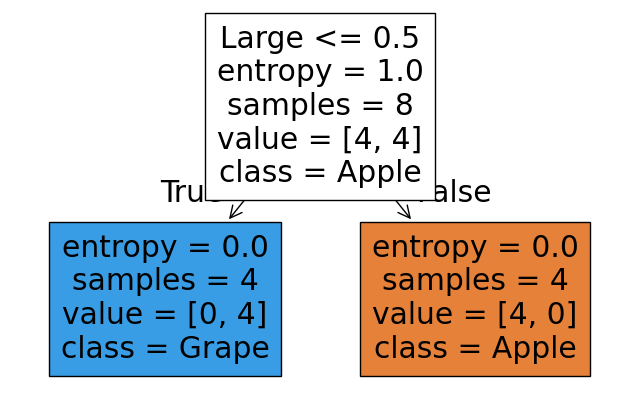

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# A tiny fruit dataset: two yes/no features and a label
df = pd.DataFrame({
    "Large": [1, 1, 0, 0, 1, 0, 1, 0],   # 1 = large, 0 = small
    "Red":   [1, 0, 1, 0, 1, 1, 0, 0],   # 1 = red,   0 = green
    "Fruit": ["Apple", "Apple", "Grape", "Grape", "Apple", "Grape", "Apple", "Grape"],
})

X = df[["Large", "Red"]]
y = df["Fruit"]

# Build the tree using entropy to choose splits
tree = DecisionTreeClassifier(criterion="entropy", random_state=0)
tree.fit(X, y)

# Show the tree as text and as a picture
print(export_text(tree, feature_names=list(X.columns)))

plt.figure(figsize=(8, 5))
plot_tree(tree, feature_names=X.columns, class_names=tree.classes_, filled=True)
plt.show()

How to read this plot??

Let's start with the root (top box). This is where we have all 8 fruits before any question is asked.


`Large <= 0.5:` is the question the tree asks. Since Large is 0 or 1, this really means "Is it small?"


`entropy = 1.0:` the group is a 50/50 mix, so it's as messy as two classes can get.


`samples = 8:` every fruit starts here.


`value = [4, 4]:` 4 apples and 4 grapes, in the order of class_names (Apple first, then Grape).


`class = Apple:` what the tree would predict if it stopped here. It's a tie, so scikit-learn picks the first class. Don't read anything into it.

Take a moment and try to read other boxes.


## **Decision Tree on Iris Dataset**


In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Decision Tree
dt = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
dt.fit(X_train, y_train)



DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [3]:
# Predict and Evaluate
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.98


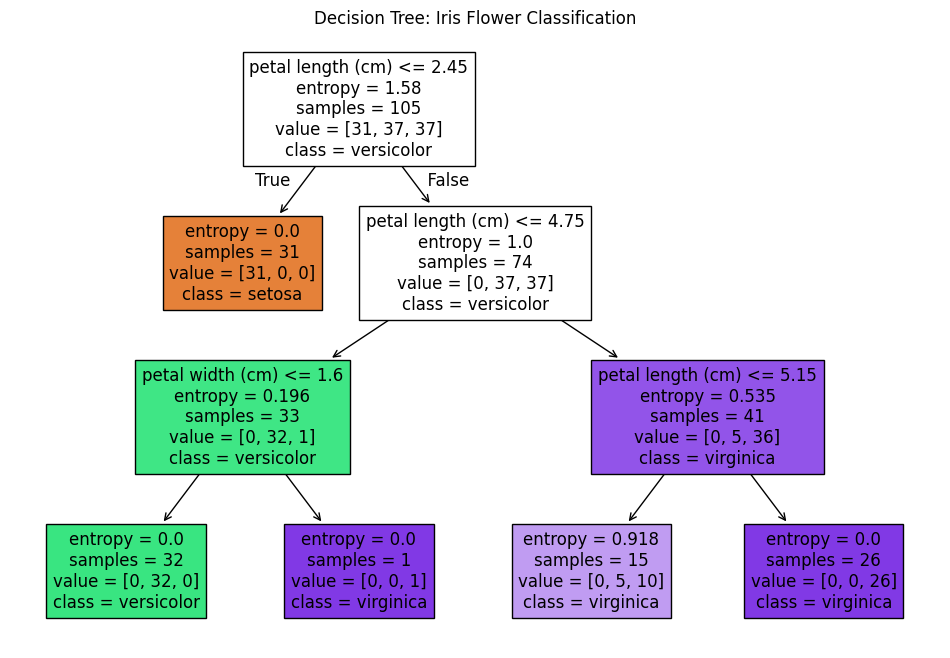

In [4]:

# Visualize the Tree
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree: Iris Flower Classification")
plt.show()

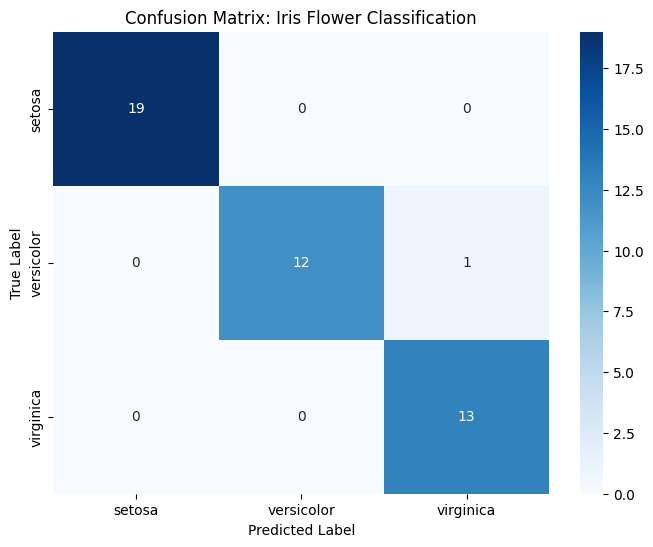

In [5]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Plot Confusion Matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix: Iris Flower Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 1. Your Turn: **Apply a decision tree to MNIST**

1. Load MNIST with `fetch_openml("mnist_784", as_frame=False)`. Each image is 784 pixel values, and the label is the digit 0–9.
2. Split the data into training and test sets with `train_test_split`, keeping 20% for testing.
3. Train a `DecisionTreeClassifier` with `criterion="entropy"`.
4. Report the accuracy on both the training set and the test set.
5. Try `max_depth` values of 5, 10, 20, and None, and record both accuracies for each.
6. In two sentences, explain which depth works best and what the gap between training and test accuracy tells you.

The full MNIST dataset has 70,000 images, so training takes a minute or so. If that's too slow for you, switch to`load_digits()`, which has 1,800 small 8×8 images and runs instantly.




In [6]:
#datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_digits
#DT and plot tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

#train test split
from sklearn.model_selection import train_test_split

#metrics
from sklearn.metrics import accuracy_score, confusion_matrix

#for plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
#Load MNIST with fetch_openml("mnist_784", as_frame=False).
digits = fetch_openml("mnist_784", as_frame=False)
X = digits.data
y = digits.target
feature_names = digits.feature_names
class_names = digits.target_names

In [8]:
# if the full dataset is too large, load the MNIST-like Digits Dataset (from sklearn)
digits = load_digits()
X = digits.data  # Features: 8x8 pixel images, flattened to 1D arrays
y = digits.target  # Target: Labels (digits 0-9)
feature_names = [f'Pixel {i}' for i in range(X.shape[1])]
class_names = [str(i) for i in range(10)]  # Digits 0 to 9


In [9]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Train Decision Trees with different depth limitations using entropy
depths = [5, 10, 20, None]
results = {}

for depth in depths:
    # Initialize and train the classifier
    dt_clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt_clf.fit(X_train, y_train)

    # Evaluate performance
    train_acc = dt_clf.score(X_train, y_train)
    test_acc = dt_clf.score(X_test, y_test)

    results[depth] = {"train_acc": train_acc, "test_acc": test_acc}
    print(f"max_depth: {str(depth):<5} | Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

max_depth: 5     | Train Accuracy: 0.8448 | Test Accuracy: 0.8139
max_depth: 10    | Train Accuracy: 0.9986 | Test Accuracy: 0.8944
max_depth: 20    | Train Accuracy: 1.0000 | Test Accuracy: 0.8889
max_depth: None  | Train Accuracy: 1.0000 | Test Accuracy: 0.8889


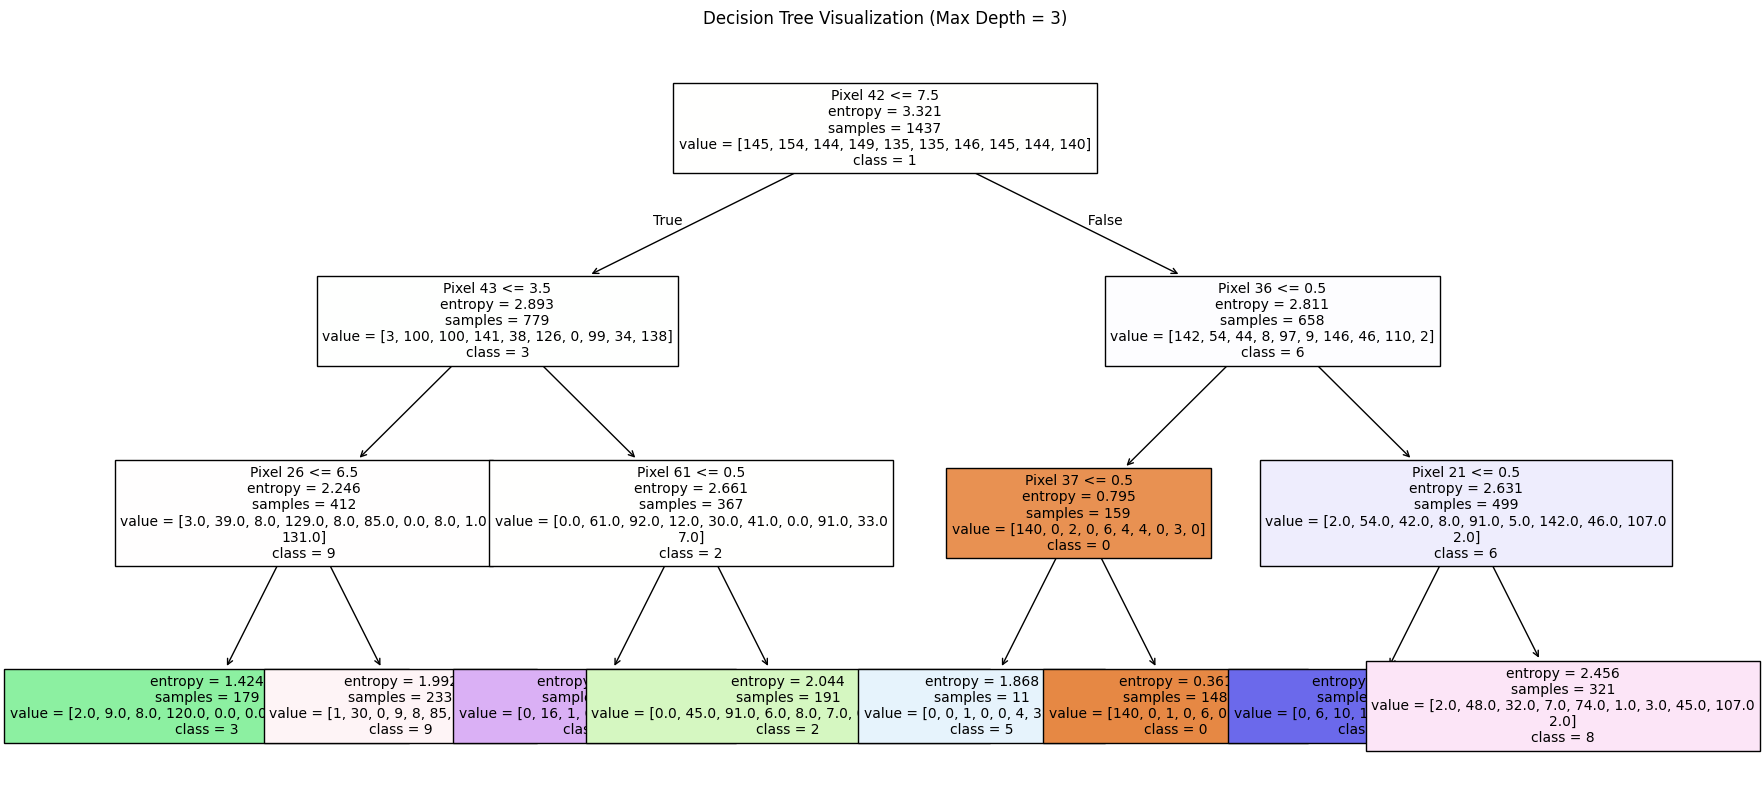

In [11]:
# Visualize the Decision Trees
vis_tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
vis_tree.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(vis_tree, feature_names=feature_names, class_names=class_names, filled=True, fontsize=10)
plt.title("Decision Tree Visualization (Max Depth = 3)")
plt.show()


In [12]:
# Find predictions and print accuracy
best_dt = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)
best_dt.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = best_dt.predict(X_test)

# Calculate and print the test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Best Decision Tree (max_depth=10) Test Accuracy: {test_accuracy:.4f}")

Best Decision Tree (max_depth=10) Test Accuracy: 0.8944


In [13]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

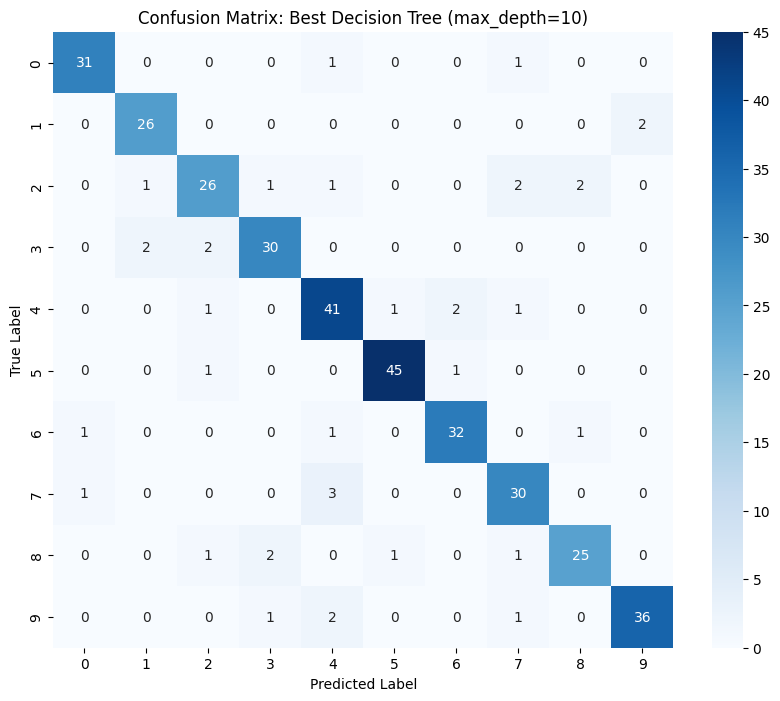

In [14]:
# Plot Confusion Matrix using Seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix: Best Decision Tree (max_depth=10)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [15]:
# Train Decision Trees with different depth limitations using 'gini' criterion
depths = [5, 10, 20, None]
gini_results = {}

print("--- GINI CRITERION RESULTS ---")
for depth in depths:
    # Initialize and train the classifier with gini
    dt_clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt_clf_gini.fit(X_train, y_train)

    # Evaluate performance
    train_acc = dt_clf_gini.score(X_train, y_train)
    test_acc = dt_clf_gini.score(X_test, y_test)

    # Get actual depth of the tree
    actual_depth = dt_clf_gini.get_depth()

    gini_results[depth] = {
        "train_acc": train_acc,
        "test_acc": test_acc,
        "actual_depth": actual_depth
    }
    print(f"max_depth limit: {str(depth):<5} | Actual Depth: {actual_depth:<2} | Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

--- GINI CRITERION RESULTS ---
max_depth limit: 5     | Actual Depth: 5  | Train Accuracy: 0.6743 | Test Accuracy: 0.6639
max_depth limit: 10    | Actual Depth: 10 | Train Accuracy: 0.9687 | Test Accuracy: 0.8500
max_depth limit: 20    | Actual Depth: 15 | Train Accuracy: 1.0000 | Test Accuracy: 0.8417
max_depth limit: None  | Actual Depth: 15 | Train Accuracy: 1.0000 | Test Accuracy: 0.8417


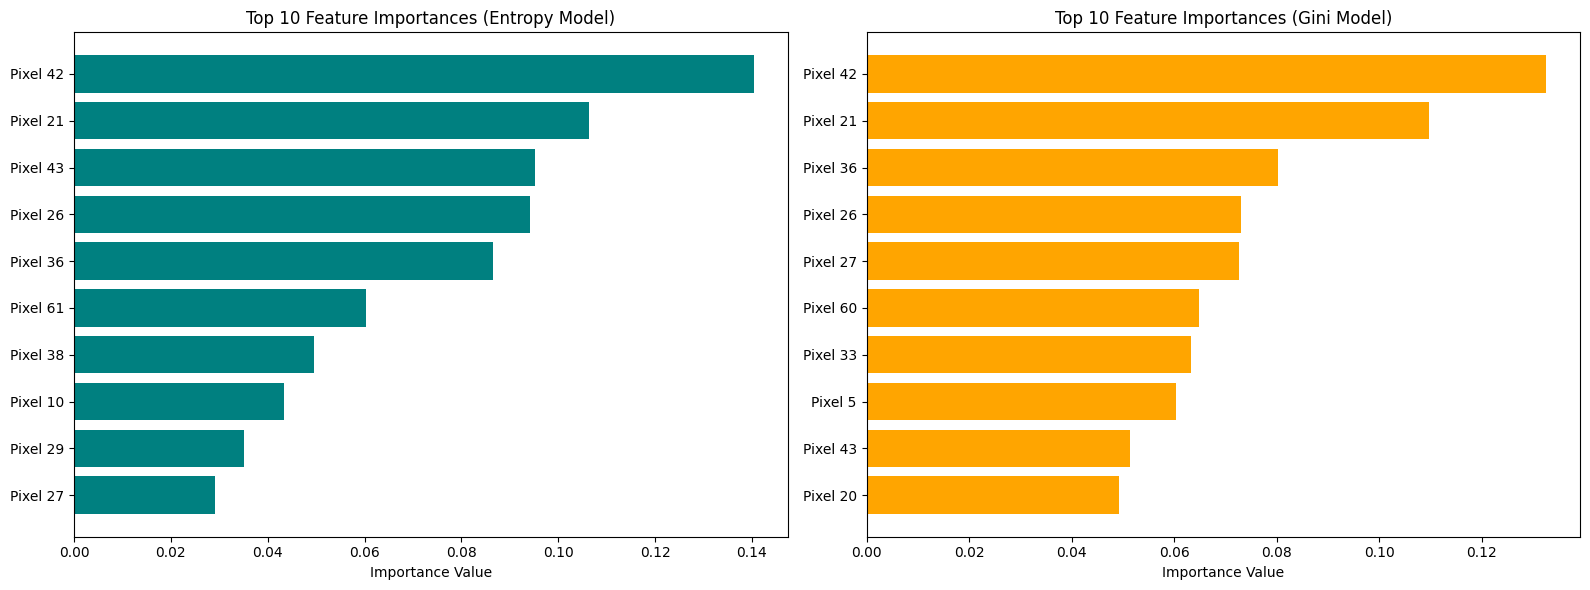

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Retrieve feature importances for both models
# best_dt was trained with criterion='entropy' and max_depth=10
# We will retrain a gini model with its best setting (max_depth=10) to do a fair comparison
best_dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
best_dt_gini.fit(X_train, y_train)

importances_entropy = best_dt.feature_importances_
importances_gini = best_dt_gini.feature_importances_

# Create a DataFrame for comparison
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Entropy Importance': importances_entropy,
    'Gini Importance': importances_gini
})

# Get top 10 features for both
top_entropy = importance_df.sort_values(by='Entropy Importance', ascending=False).head(10)
top_gini = importance_df.sort_values(by='Gini Importance', ascending=False).head(10)

# Plot the comparisons side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Entropy Plot
axes[0].barh(top_entropy['Feature'], top_entropy['Entropy Importance'], color='teal')
axes[0].set_title('Top 10 Feature Importances (Entropy Model)')
axes[0].set_xlabel('Importance Value')
axes[0].invert_yaxis()  # Top feature at the top

# Gini Plot
axes[1].barh(top_gini['Feature'], top_gini['Gini Importance'], color='orange')
axes[1].set_title('Top 10 Feature Importances (Gini Model)')
axes[1].set_xlabel('Importance Value')
axes[1].invert_yaxis()  # Top feature at the top

plt.tight_layout()
plt.show()

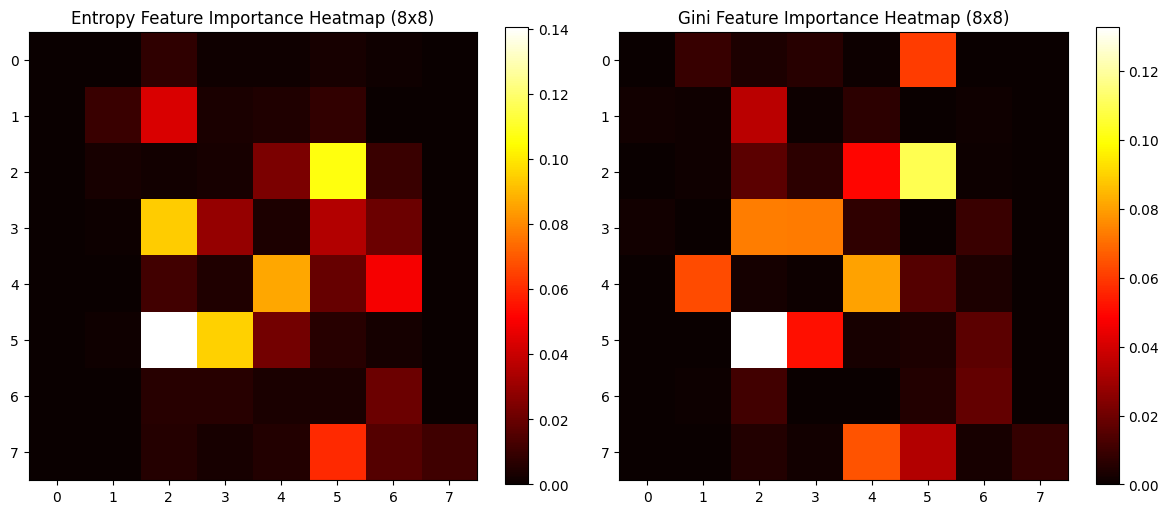

In [17]:
# Reshape the importances back into the original 8x8 image shape to see a "heatmap" of where the models look
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im_entropy = axes[0].imshow(importances_entropy.reshape(8, 8), cmap='hot', interpolation='nearest')
axes[0].set_title('Entropy Feature Importance Heatmap (8x8)')
fig.colorbar(im_entropy, ax=axes[0])

im_gini = axes[1].imshow(importances_gini.reshape(8, 8), cmap='hot', interpolation='nearest')
axes[1].set_title('Gini Feature Importance Heatmap (8x8)')
fig.colorbar(im_gini, ax=axes[1])

plt.tight_layout()
plt.show()

When the entropy of feature is high it seems to share nearly exact values, otherwise there is no distinguishable relationship.

In [18]:
# 1. Train with Gini criterion and our best max_depth setting (10)
best_dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
best_dt_gini.fit(X_train, y_train)

# 2. Evaluate Gini performance
gini_train_acc = best_dt_gini.score(X_train, y_train)
gini_test_acc = best_dt_gini.score(X_test, y_test)
gini_depth = best_dt_gini.get_depth()

# 3. Print Comparison
print("--- COMPARISON: ENTROPY VS GINI (max_depth=10) ---")
print(f"Entropy Model - Train Accuracy: 0.9986 | Test Accuracy: 0.8944 | Actual Depth: 10")
print(f"Gini Model    - Train Accuracy: {gini_train_acc:.4f} | Test Accuracy: {gini_test_acc:.4f} | Actual Depth: {gini_depth}")

--- COMPARISON: ENTROPY VS GINI (max_depth=10) ---
Entropy Model - Train Accuracy: 0.9986 | Test Accuracy: 0.8944 | Actual Depth: 10
Gini Model    - Train Accuracy: 0.9687 | Test Accuracy: 0.8500 | Actual Depth: 10


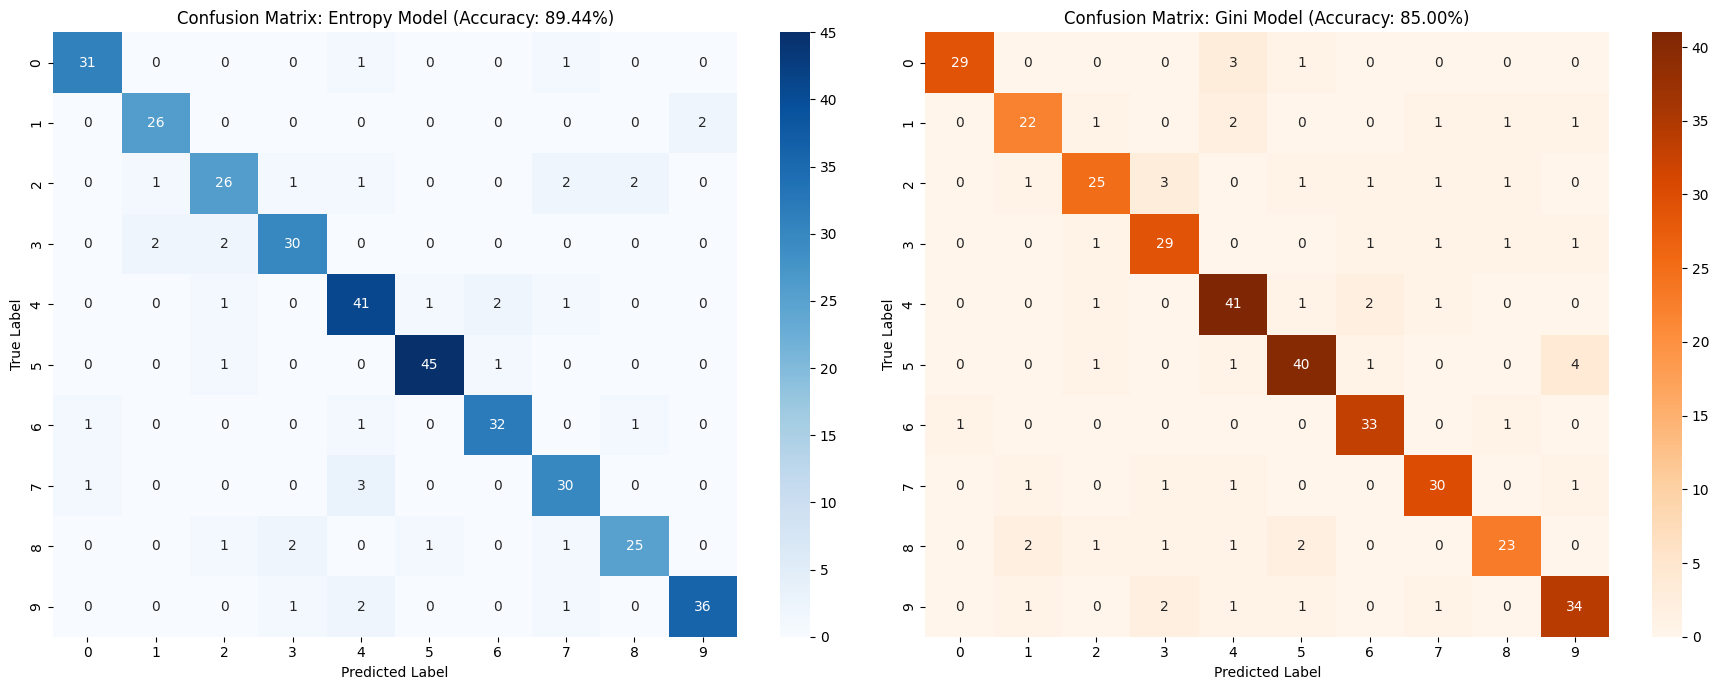

In [19]:
# Generate predictions using our Gini model
y_pred_gini = best_dt_gini.predict(X_test)

# Calculate confusion matrix for the Gini model
conf_matrix_gini = confusion_matrix(y_test, y_pred_gini)

# Plot both confusion matrices side-by-side for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Entropy Heatmap (conf_matrix holds entropy predictions from previous cells)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix: Entropy Model (Accuracy: 89.44%)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Gini Heatmap
sns.heatmap(conf_matrix_gini, annot=True, fmt="d", cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix: Gini Model (Accuracy: 85.00%)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

##2.
 Now switch to criterion="gini" and train again with your best settings. How do the accuracy and the tree depth compare with entropy? Look up Gini impurity to see what it measures and how it differs from entropy.




##3.
 Which settings gave the best test accuracy? What does the gap between training and test accuracy tell you about the model?

The features with the entropy criterion are: max_depth=5 (low overfitting but underfitting), max_depth=10 (optimal balance). With the gini criterion, the best features are: max_depth=10,